# 09 Interactive SRG Explorer

`eucare.shrink_rotate.ShrinkRotateExplorer` packages an interactive widget on top of an SRG graph: drag the sliders to vary the shrink factor and rotation angle and see the crease pattern update live. Toggle *folded* to preview the folded form, or *reparametrized* to switch to the equivalent (β, γ) parametrisation.

Requires the `notebook` extra (`pip install 'eucare[notebook]'`) and a Jupyter kernel with `%matplotlib widget`.

In [3]:
%matplotlib widget
import eucare as ec
from eucare.example_graphs import from_tiles
from eucare.example_tilesets import t_4_6_12
from eucare.shrink_rotate import (
    assign_this_way_by_bfs,
    shrink_rotate_pattern,
)
from eucare.shrink_rotate import ShrinkRotateExplorer

In [5]:
# Build a tiling, assign face z-order (controls mountain/valley), and build the SRG.
G = from_tiles(t_4_6_12(), rings=3)
for f in G.faces:
    f['z_order'] = f.order()
assign_this_way_by_bfs(G, G.central_face())

SRG = shrink_rotate_pattern(G)
SRG.join_order_2_boundary_vertices()  # make the boundary a little nicer

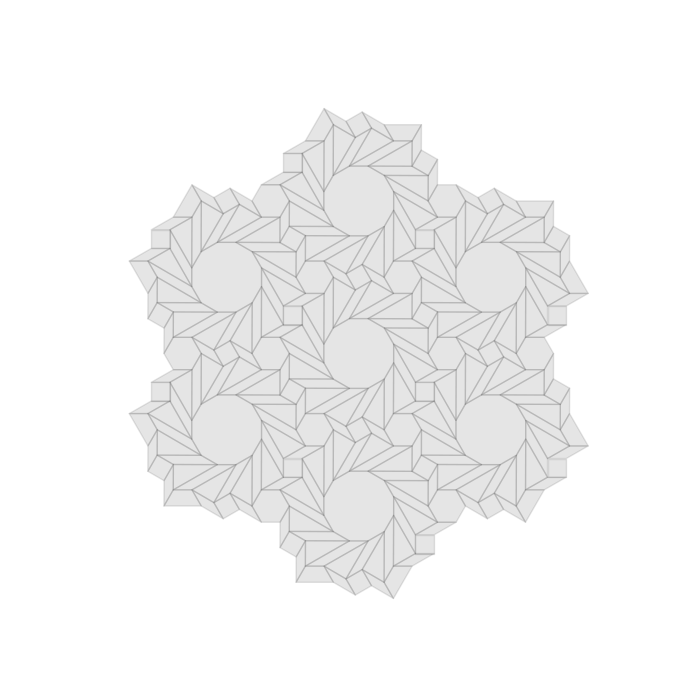

Output()

In [6]:
explorer = ShrinkRotateExplorer(SRG)
explorer.display()

The widget mutates `v['pos']` on the SRG in place at every tick, so downstream operations like `eucare.overlap.fold_complete(SRG)` always operate on the currently-displayed geometry.

In [ ]:
SRG.show()